In [1]:
from langgraph.graph import StateGraph ,START , END
from typing import TypedDict


In [2]:
from typing import TypedDict

class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    result: str 

In [3]:
def calculate_bmi(state: BMIState):
    bmi = state["weight"] / (state["height"] ** 2)

    return {
        "bmi": round(bmi, 2)
    }

In [4]:
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [5]:
def getllmresponse(state: BMIState):

    prompt = f"""
    You are a professional fitness and nutrition coach.

    User Details:
    Weight: {state['weight']} kg
    Height: {state['height']} m
    BMI: {state['bmi']}

    Based on the BMI:
    1. Tell the BMI category.
    2. Explain what it means.
    3. Give diet suggestions.
    4. Give exercise suggestions.
    5. Mention precautions.
    6. Keep the answer simple and motivating.
    """

    response = llm.invoke(prompt)

    return {
        "result": response.content
    }

In [6]:
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [7]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(BMIState)

# Nodes
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("llm_response", getllmresponse)

# Edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "llm_response")
graph.add_edge("llm_response", END)

workflow = graph.compile()

In [8]:
result = workflow.invoke({
    "weight": 70,
    "height": 1.75
})

print(result["result"])

Congratulations on taking the first step towards a healthier lifestyle!

**Your BMI Category:**
Your BMI (22.86) falls into the **Normal** category.

**What it means:**
Having a normal BMI indicates that your weight is within a healthy range for your height. You're at a low risk for health problems associated with being overweight or underweight. Keep in mind that BMI is not a perfect measure, but it's a good starting point.

**Diet Suggestions:**
To maintain your healthy weight, focus on:

1. **Balanced meals**: Eat a variety of whole foods, including fruits, vegetables, whole grains, lean proteins, and healthy fats.
2. **Hydration**: Drink plenty of water throughout the day.
3. **Portion control**: Eat until you're satisfied, not stuffed.
4. **Healthy snacking**: Choose fruits, nuts, or energy bars instead of junk food.
5. **Limit processed foods**: Try to avoid or limit foods high in sugar, salt, and unhealthy fats.

**Exercise Suggestions:**
To stay healthy and maintain your weight

In [9]:
print(result)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'result': "Congratulations on taking the first step towards a healthier lifestyle!\n\n**Your BMI Category:**\nYour BMI (22.86) falls into the **Normal** category.\n\n**What it means:**\nHaving a normal BMI indicates that your weight is within a healthy range for your height. You're at a low risk for health problems associated with being overweight or underweight. Keep in mind that BMI is not a perfect measure, but it's a good starting point.\n\n**Diet Suggestions:**\nTo maintain your healthy weight, focus on:\n\n1. **Balanced meals**: Eat a variety of whole foods, including fruits, vegetables, whole grains, lean proteins, and healthy fats.\n2. **Hydration**: Drink plenty of water throughout the day.\n3. **Portion control**: Eat until you're satisfied, not stuffed.\n4. **Healthy snacking**: Choose fruits, nuts, or energy bars instead of junk food.\n5. **Limit processed foods**: Try to avoid or limit foods high in sugar, salt, and unhealthy fa

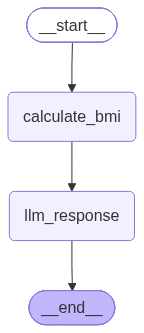

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [11]:
from pydantic import BaseModel , Field
from dotenv import load_dotenv

In [12]:
class feedbacksession(BaseModel):
    feedback : str 
    score : int 

In [13]:
structured_output = llm.with_structured_output(feedbacksession)

In [14]:
essays = """# Who is Mahatma Gandhi?

Mahatma Gandhi, whose full name was Mohandas Karamchand Gandhi, was one of the greatest leaders in the history of India. He is known as the "Father of the Nation" because of his significant role in India's struggle for independence from British rule. Gandhi was born on October 2, 1869, in Porbandar, Gujarat.

Gandhi studied law in England and later worked in South Africa, where he experienced racial discrimination. These experiences inspired him to fight against injustice through peaceful means. He believed in the principles of truth (*Satya*) and non-violence (*Ahimsa*), which became the foundation of his movements.

After returning to India, Gandhi led several important movements, including the Non-Cooperation Movement, the Civil Disobedience Movement, and the Quit India Movement. One of his most famous protests was the Dandi Salt March in 1930, where he opposed the British salt tax through peaceful protest. His leadership inspired millions of Indians to join the freedom struggle.

Gandhi believed that real strength comes from peace, honesty, and self-discipline. He encouraged people to wear *khadi* (hand-spun cloth), promote village industries, and live simple lives. His teachings continue to inspire people around the world to solve conflicts without violence.

On January 30, 1948, Mahatma Gandhi was assassinated in New Delhi. Although he is no longer alive, his ideas and values remain influential across the world. Every year, his birthday, October 2, is celebrated as Gandhi Jayanti in India and as the International Day of Non-Violence by the United Nations.

In conclusion, Mahatma Gandhi was a remarkable leader who showed that courage, truth, and non-violence can bring about great social and political change. His life continues to inspire people to work for peace, justice, and equality.
"""

In [15]:
prompts = f"give  me feedback and score of this essays here is {essays}"

structured_output.invoke(prompts)


feedbacksession(feedback="The essay is well-structured and provides a clear overview of Mahatma Gandhi's life and achievements. However, it lacks specific details and quotes from Gandhi's works, and some sentences are quite general. The conclusion is a good summary, but it could be more impactful if it included a personal reflection or a call to action.", score=7)

In [16]:
query = "what is full form of ai"
result = llm.invoke(query)
print(result.content)

The full form of AI is Artificial Intelligence.


In [17]:
from langchain_core.messages import BaseMessage , HumanMessage
from typing import Annotated , TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph ,START , END

In [18]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage] ,add_messages] 
    

In [19]:
graphs = StateGraph(ChatState)

In [20]:
def chat_nodes(state : ChatState):
    messages = state['messages']

    response = llm.invoke(messages)
    return {
        "messages" : [response]
    }

In [21]:
# add nodes 

graphs.add_node('chat_nodes' , chat_nodes)

# add edges 

graphs.add_edge(START , 'chat_nodes')
graphs.add_edge('chat_nodes' , END)



In [22]:
chatbot = graphs.compile()

In [23]:
initial_node = {
    "messages" : HumanMessage(content='who is the prime minister of india')
}

In [24]:
chatbot.invoke(initial_node)

{'messages': [HumanMessage(content='who is the prime minister of india', additional_kwargs={}, response_metadata={}, id='1ef6a30a-f2ad-44de-a2a9-3c85c3fd2f4c'),
  AIMessage(content='The current Prime Minister of India is Narendra Modi. He has been serving as the Prime Minister of India since May 26, 2014. He won his second term in the 2019 general election and was sworn in as the Prime Minister for the second time on May 30, 2019.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 42, 'total_tokens': 105, 'completion_time': 0.099186732, 'completion_tokens_details': None, 'prompt_time': 0.002072178, 'prompt_tokens_details': None, 'queue_time': 0.052226751, 'total_time': 0.10125891}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fca7e-7adc-7963-bac9-1c3356cda296-0', tool_calls=[], invalid_tool_ca

In [25]:
while True:

    user_input = input("Ente ther query here okay") 

    print("USer Enter :  " , user_input)

    if user_input.lower().strip() in ['exit' , 'by' , 'stop']:
        break

    response = chatbot.invoke({

        'messages' : [HumanMessage(content=user_input)]
    })

    result  = response['messages'][-1].content

    print(result)

USer Enter :   exit


In [26]:
from langgraph.checkpoint.memory import InMemorySaver


In [27]:
from typing import TypedDict
from langgraph.graph import StateGraph , START , END

In [28]:
class jokesstate(TypedDict):
    topic:str 
    jokes:str
    explanation : str 
    

In [29]:
def generate_jock(state:jokesstate):
    prompts = f"generate a jocks  on this topics {state['topic']}"

    response = llm.invoke(prompts)

    return{
        "jokes" : response.content
    }

In [30]:
def jock_explanation(state:jokesstate):
    prompts = f"Generate jokes explanation of this topics {state['jokes']}"
    response = llm.invoke(prompts)

    return {
        'explanation' : response.content
    }

In [31]:
graph = StateGraph(jokesstate)

In [32]:
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [33]:
#add nodes 
graph.add_node('generate_jockes' , generate_jock)
graph.add_node('generate_explanation' , jock_explanation)

# add edges 

graph.add_edge(START , 'generate_jockes')
graph.add_edge('generate_jockes' , 'generate_explanation')
graph.add_edge('generate_explanation' , END)


checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [34]:
configs = {
    'configurable' : {"thread_id" : "1"}
}

workflow.invoke({"topic" : "pizza"} , config=configs)


{'topic': 'pizza',
 'jokes': '**The Ultimate Pizza Showdown**\n\n**Topic: The Perfect Cheese for Pizza**\n\n**Jock 1: "The Cheese Whiz"**\nName: Vinnie "The Slice" LaRosa\nSport: Pizza Tossing\nBackground: Vinnie is a three-time Pizza Tossing champion and has a reputation for being one of the most skilled pizza throwers in the game.\n\n**Argument:** "You can\'t have a good pizza without a blend of melted mozzarella and parmesan cheese. It\'s the classic combo that\'s been perfected over the years. The creaminess of mozzarella and the saltiness of parmesan create a flavor profile that\'s unmatched."\n\n**Jock 2: "The Rebel"**\nName: Axel "The Axe" Adams\nSport: Pizza Delivery\nBackground: Axel is a former pizza delivery driver turned pizza rebel, known for his unconventional pizza topping combinations and unorthodox delivery methods.\n\n**Argument:** "Mozzarella and parmesan are boring. You want to mix it up with some feta, goat cheese, or even blue cheese. The tanginess and creaminess 

In [35]:
workflow.get_state(configs)

StateSnapshot(values={'topic': 'pizza', 'jokes': '**The Ultimate Pizza Showdown**\n\n**Topic: The Perfect Cheese for Pizza**\n\n**Jock 1: "The Cheese Whiz"**\nName: Vinnie "The Slice" LaRosa\nSport: Pizza Tossing\nBackground: Vinnie is a three-time Pizza Tossing champion and has a reputation for being one of the most skilled pizza throwers in the game.\n\n**Argument:** "You can\'t have a good pizza without a blend of melted mozzarella and parmesan cheese. It\'s the classic combo that\'s been perfected over the years. The creaminess of mozzarella and the saltiness of parmesan create a flavor profile that\'s unmatched."\n\n**Jock 2: "The Rebel"**\nName: Axel "The Axe" Adams\nSport: Pizza Delivery\nBackground: Axel is a former pizza delivery driver turned pizza rebel, known for his unconventional pizza topping combinations and unorthodox delivery methods.\n\n**Argument:** "Mozzarella and parmesan are boring. You want to mix it up with some feta, goat cheese, or even blue cheese. The tangi

In [36]:
list(workflow.get_state_history(configs))

[StateSnapshot(values={'topic': 'pizza', 'jokes': '**The Ultimate Pizza Showdown**\n\n**Topic: The Perfect Cheese for Pizza**\n\n**Jock 1: "The Cheese Whiz"**\nName: Vinnie "The Slice" LaRosa\nSport: Pizza Tossing\nBackground: Vinnie is a three-time Pizza Tossing champion and has a reputation for being one of the most skilled pizza throwers in the game.\n\n**Argument:** "You can\'t have a good pizza without a blend of melted mozzarella and parmesan cheese. It\'s the classic combo that\'s been perfected over the years. The creaminess of mozzarella and the saltiness of parmesan create a flavor profile that\'s unmatched."\n\n**Jock 2: "The Rebel"**\nName: Axel "The Axe" Adams\nSport: Pizza Delivery\nBackground: Axel is a former pizza delivery driver turned pizza rebel, known for his unconventional pizza topping combinations and unorthodox delivery methods.\n\n**Argument:** "Mozzarella and parmesan are boring. You want to mix it up with some feta, goat cheese, or even blue cheese. The tang